# Stochastic BML Traffic Model

The **Stochastic BML model** extends the deterministic Biham–Middleton–Levine (1992)
cellular automaton with a **NaSch-style randomisation step**: each car that *could* move
(i.e. the target cell is empty) is instead frozen with probability $p_{\text{rand}}$.

| Model | Dimension | Stochastic? | Transition |
|---|---|---|---|
| NaSch | 1-D | Yes ($p_{\text{rand}} = 0.3$) | Smooth hump |
| BML | 2-D | No | Sharp discontinuous drop |
| **Stochastic BML** | **2-D** | **Yes** | **Softened transition** |

- $p_{\text{rand}} = 0$: recovers the **deterministic BML** exactly — same sharp phase transition.
- $p_{\text{rand}} > 0$: reduces free-flow throughput, shifts $\rho_c$, and softens the discontinuity.

This bridges the two main models studied in this project.

In [1]:
# ── Section 1: Imports and global parameters ──────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

L         = 100    # grid size (L × L cells)
T_WARMUP  = 500    # transient steps discarded before measurement
T_MEASURE = 200    # steps averaged for flow
P_RAND    = 0.3    # default NaSch randomisation probability

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

## Section 2: Model — BML with NaSch Randomisation

### Grid encoding (identical to deterministic BML)

| Value | Meaning |
|---|---|
| 0 | Empty cell |
| 1 | Horizontal car (→) |
| 2 | Vertical car (↑) |

### Modified update rules

Each full timestep consists of two simultaneous sub-steps:

1. **Horizontal phase**: every type-1 car at $(r, c)$ attempts to move to
   $(r,\, c{+}1 \bmod L)$.  The move succeeds only if (a) the target is empty
   **and** (b) the car is not frozen by the stochastic dawdling rule.
2. **Vertical phase**: same logic, type-2 cars move to $(r{-}1 \bmod L,\, c)$.

**Stochastic dawdling rule** (from NaSch): after checking that the target is empty,
each moveable car is independently frozen with probability $p_{\text{rand}}$.
Setting $p_{\text{rand}} = 0$ recovers the fully deterministic BML.

$$
\text{car moves} \iff \text{target empty} \;\wedge\; U_i > p_{\text{rand}},
\quad U_i \sim \mathrm{Uniform}(0,1)
$$

In [2]:
# ── Section 2a: BML base class (self-contained copy) ──────────────────────
class BML:
    '''
    Biham-Middleton-Levine 2-D traffic cellular automaton.

    Grid: L x L array (int8).  0 = empty, 1 = horizontal car, 2 = vertical car.
    Boundary: periodic (torus).

    One full timestep:
      Phase 1  - horizontal cars move right (if target empty)
      Phase 2  - vertical cars move up   (if target empty)
    Both phases are evaluated simultaneously on the state *before* any move
    in that phase is applied.
    '''

    def __init__(self, L, density, r_horiz=0.5, seed=None):
        self.L = L
        self.t = 0
        rng    = np.random.default_rng(seed)

        n_total = int(round(density * L * L))
        n_horiz = int(round(r_horiz * n_total))
        n_vert  = n_total - n_horiz

        flat      = rng.permutation(L * L)
        self.grid = np.zeros(L * L, dtype=np.int8)
        self.grid[flat[:n_horiz]]                  = 1
        self.grid[flat[n_horiz:n_horiz + n_vert]]  = 2
        self.grid = self.grid.reshape(L, L)

    def _move_horizontal(self):
        can_move = (self.grid == 1) & (np.roll(self.grid, -1, axis=1) == 0)
        n_moved  = int(can_move.sum())
        if n_moved:
            g = self.grid.copy()
            g[can_move] = 0
            g[np.roll(can_move, 1, axis=1)] = 1
            self.grid = g
        return n_moved

    def _move_vertical(self):
        can_move = (self.grid == 2) & (np.roll(self.grid, 1, axis=0) == 0)
        n_moved  = int(can_move.sum())
        if n_moved:
            g = self.grid.copy()
            g[can_move] = 0
            g[np.roll(can_move, -1, axis=0)] = 2
            self.grid = g
        return n_moved

    def step(self):
        n_total = int((self.grid > 0).sum())
        moved_h = self._move_horizontal()
        moved_v = self._move_vertical()
        self.t += 1
        return (moved_h + moved_v) / max(n_total, 1)

    def warmup(self, T=None):
        for _ in range(T or T_WARMUP):
            self.step()

    def run(self, T=None):
        T = T or T_MEASURE
        return float(np.mean([self.step() for _ in range(T)]))

    def get_snapshot(self):
        return self.grid.copy()

    def density(self):
        return float((self.grid > 0).sum()) / self.L ** 2

    def is_gridlocked(self):
        h_free = ((self.grid == 1) & (np.roll(self.grid, -1, axis=1) == 0)).any()
        v_free = ((self.grid == 2) & (np.roll(self.grid,  1, axis=0) == 0)).any()
        return not (h_free or v_free)


def run_sweep(L, densities, seed_offset=0, T_warmup=T_WARMUP, T_measure=T_MEASURE):
    flows = np.zeros(len(densities))
    for i, rho in enumerate(densities):
        sim      = BML(L=L, density=rho, r_horiz=0.5, seed=seed_offset + i)
        sim.warmup(T_warmup)
        flows[i] = sim.run(T_measure)
    return flows

In [3]:
# ── Section 2b: StochasticBML class ───────────────────────────────────────
class StochasticBML(BML):
    '''
    BML with NaSch-style stochastic dawdling.

    Each car that *could* move (target cell empty) is independently frozen
    with probability p_rand before movement is applied.

    p_rand = 0.0  =>  identical to deterministic BML.
    p_rand = 0.3  =>  matches the default NaSch randomisation probability.
    '''

    def __init__(self, L, density, p_rand=0.0, r_horiz=0.5, seed=None):
        super().__init__(L=L, density=density, r_horiz=r_horiz, seed=seed)
        self.p_rand = p_rand
        # BML base class uses rng only as a local variable in __init__;
        # we store our own instance for use in the movement methods.
        self.rng = np.random.default_rng(seed)

    def _move_horizontal(self):
        '''
        Horizontal cars move right if the cell to the right is empty,
        unless stochastically frozen (prob p_rand).
        '''
        can_move = (self.grid == 1) & (np.roll(self.grid, -1, axis=1) == 0)
        if self.p_rand > 0:
            # freeze each moveable car independently with prob p_rand
            can_move &= ~(self.rng.random(self.grid.shape) < self.p_rand)
        n_moved = int(can_move.sum())
        if n_moved:
            g = self.grid.copy()
            g[can_move] = 0
            g[np.roll(can_move, 1, axis=1)] = 1
            self.grid = g
        return n_moved

    def _move_vertical(self):
        '''
        Vertical cars move up if the cell above is empty,
        unless stochastically frozen (prob p_rand).
        '''
        can_move = (self.grid == 2) & (np.roll(self.grid, 1, axis=0) == 0)
        if self.p_rand > 0:
            can_move &= ~(self.rng.random(self.grid.shape) < self.p_rand)
        n_moved = int(can_move.sum())
        if n_moved:
            g = self.grid.copy()
            g[can_move] = 0
            g[np.roll(can_move, -1, axis=0)] = 2
            self.grid = g
        return n_moved
    # step(), warmup(), run(), get_snapshot(), is_gridlocked() all inherited from BML


# ── Sanity checks ─────────────────────────────────────────────────────────
# 1. p_rand=0 should produce the same initial grid as BML for the same seed
sim_det = BML(L=20, density=0.2, seed=0)
sim_sto = StochasticBML(L=20, density=0.2, p_rand=0.0, seed=0)
print('p_rand=0 initial grid matches BML:', np.array_equal(sim_det.grid, sim_sto.grid))

# 2. p_rand=0.3 should still run without error
sim_s = StochasticBML(L=30, density=0.25, p_rand=0.3, seed=42)
sim_s.warmup(50)
flow_test = sim_s.run(T=20)
print(f'StochasticBML (p=0.3) mean flow (20 steps): {flow_test:.3f}')
print(f'Gridlocked? {sim_s.is_gridlocked()}')

p_rand=0 initial grid matches BML: True
StochasticBML (p=0.3) mean flow (20 steps): 0.439
Gridlocked? False


In [4]:
# ── Section 8a: BMLWithLights base (self-contained copy) ──────────────────
class BMLWithLights(BML):
    '''
    BML model extended with traffic lights at a grid of intersection cells.

    Light schedule (per timestep t):
      phase = t % T_cycle
      if phase < T_green_h  -> horizontal green, vertical red
      else                  -> vertical green, horizontal red
    '''

    def __init__(self, L, density, n_lights=4, T_cycle=20, T_green_h=None,
                 r_horiz=0.5, seed=None):
        super().__init__(L=L, density=density, r_horiz=r_horiz, seed=seed)
        self.n_lights  = n_lights
        self.T_cycle   = T_cycle
        self.T_green_h = T_green_h if T_green_h is not None else T_cycle // 2
        self.t         = 0

        spacing = L // (n_lights + 1)
        idx     = np.array([spacing * (i + 1) for i in range(n_lights)])
        self.light_rows = idx
        self.light_cols = idx
        self._mask = np.zeros((L, L), dtype=bool)
        for r in idx:
            for c in idx:
                self._mask[r, c] = True

    def _horiz_green(self):
        return self.t % self.T_cycle < self.T_green_h

    def _move_horizontal(self):
        target   = np.roll(self.grid, -1, axis=1)
        can_move = (self.grid == 1) & (target == 0)
        if not self._horiz_green():
            can_move &= ~np.roll(self._mask, -1, axis=1)
        n_moved = int(can_move.sum())
        if n_moved:
            g = self.grid.copy()
            g[can_move] = 0
            g[np.roll(can_move, 1, axis=1)] = 1
            self.grid = g
        return n_moved

    def _move_vertical(self):
        target   = np.roll(self.grid, 1, axis=0)
        can_move = (self.grid == 2) & (target == 0)
        if self._horiz_green():
            can_move &= ~np.roll(self._mask, -1, axis=0)
        n_moved = int(can_move.sum())
        if n_moved:
            g = self.grid.copy()
            g[can_move] = 0
            g[np.roll(can_move, -1, axis=0)] = 2
            self.grid = g
        return n_moved

    def step(self):
        n_total = int((self.grid > 0).sum())
        moved_h = self._move_horizontal()
        moved_v = self._move_vertical()
        self.t += 1
        return (moved_h + moved_v) / max(n_total, 1)


# ── Section 8b: StochasticBMLWithLights ───────────────────────────────────
class StochasticBMLWithLights(StochasticBML):
    '''
    StochasticBML extended with traffic lights.

    Movement is suppressed when EITHER:
      (a) the target cell is a red-phase intersection, OR
      (b) the car is stochastically frozen (prob p_rand).

    p_rand = 0  =>  identical to BMLWithLights.
    '''

    def __init__(self, L, density, p_rand=P_RAND, n_lights=4, T_cycle=20,
                 T_green_h=None, r_horiz=0.5, seed=None):
        super().__init__(L=L, density=density, p_rand=p_rand,
                         r_horiz=r_horiz, seed=seed)
        self.n_lights  = n_lights
        self.T_cycle   = T_cycle
        self.T_green_h = T_green_h if T_green_h is not None else T_cycle // 2
        self.t         = 0

        spacing = L // (n_lights + 1)
        idx     = np.array([spacing * (i + 1) for i in range(n_lights)])
        self.light_rows = idx
        self.light_cols = idx
        self._mask = np.zeros((L, L), dtype=bool)
        for r in idx:
            for c in idx:
                self._mask[r, c] = True

    def _horiz_green(self):
        return self.t % self.T_cycle < self.T_green_h

    def _move_horizontal(self):
        target   = np.roll(self.grid, -1, axis=1)
        can_move = (self.grid == 1) & (target == 0)
        # light blocking: suppress moves into red-phase intersections
        if not self._horiz_green():
            can_move &= ~np.roll(self._mask, -1, axis=1)
        # stochastic dawdling
        if self.p_rand > 0:
            can_move &= ~(self.rng.random(self.grid.shape) < self.p_rand)
        n_moved = int(can_move.sum())
        if n_moved:
            g = self.grid.copy()
            g[can_move] = 0
            g[np.roll(can_move, 1, axis=1)] = 1
            self.grid = g
        return n_moved

    def _move_vertical(self):
        target   = np.roll(self.grid, 1, axis=0)
        can_move = (self.grid == 2) & (target == 0)
        if self._horiz_green():
            can_move &= ~np.roll(self._mask, -1, axis=0)
        if self.p_rand > 0:
            can_move &= ~(self.rng.random(self.grid.shape) < self.p_rand)
        n_moved = int(can_move.sum())
        if n_moved:
            g = self.grid.copy()
            g[can_move] = 0
            g[np.roll(can_move, -1, axis=0)] = 2
            self.grid = g
        return n_moved

    def step(self):
        n_total = int((self.grid > 0).sum())
        moved_h = self._move_horizontal()
        moved_v = self._move_vertical()
        self.t += 1
        return (moved_h + moved_v) / max(n_total, 1)


# ── Sanity check ──────────────────────────────────────────────────────────
sim_tl = StochasticBMLWithLights(L=20, density=0.3, p_rand=0.0, n_lights=2,
                                  T_cycle=10, seed=0)
print('StochasticBMLWithLights (p=0) defined.')
print(f'  Intersection cells: {[(r,c) for r in sim_tl.light_rows for c in sim_tl.light_cols]}')
print(f'  T_cycle={sim_tl.T_cycle}, T_green_h={sim_tl.T_green_h}, p_rand={sim_tl.p_rand}')

StochasticBMLWithLights (p=0) defined.
  Intersection cells: [(np.int64(6), np.int64(6)), (np.int64(6), np.int64(12)), (np.int64(12), np.int64(6)), (np.int64(12), np.int64(12))]
  T_cycle=10, T_green_h=5, p_rand=0.0


## Section 3: Fundamental Diagram — Flow vs Density

We sweep $\rho \in [0.02,\, 0.98]$ for four values of $p_{\text{rand}}$ and overlay
the resulting flow curves.

**Expected effects of increasing $p_{\text{rand}}$:**
- **Free-flow regime** ($\rho < \rho_c$): flow decreases monotonically — each car
  that could move now has a chance of staying put.
- **Phase transition**: the sharp drop is softened and the apparent $\rho_c$ shifts.
- **Gridlock regime** ($\rho > \rho_c$): already zero; stochasticity may allow partial
  recovery from near-gridlock states that would be permanent in the deterministic model.

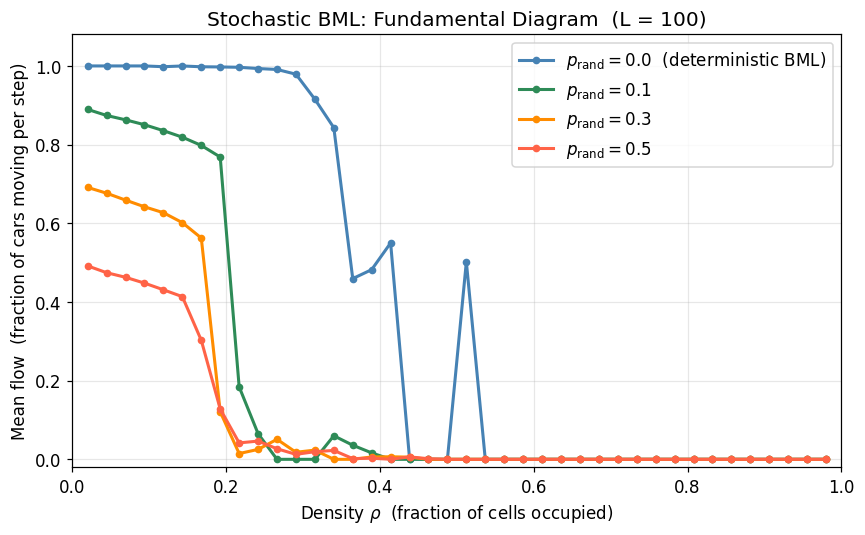

In [5]:
# ── Section 3: Fundamental diagram ────────────────────────────────────────
def run_sweep_stochastic(L, densities, p_rand, T_warmup=T_WARMUP,
                         T_measure=T_MEASURE, seed_offset=0):
    '''Run StochasticBML at each density; return array of mean flows.'''
    flows = np.zeros(len(densities))
    for i, rho in enumerate(densities):
        sim      = StochasticBML(L=L, density=rho, p_rand=p_rand,
                                 r_horiz=0.5, seed=seed_offset + i)
        sim.warmup(T_warmup)
        flows[i] = sim.run(T_measure)
    return flows


densities_fd = np.linspace(0.02, 0.98, 40)
p_rand_vals  = [0.0, 0.1, 0.3, 0.5]
fd_colors    = ['steelblue', 'seagreen', 'darkorange', 'tomato']

all_flows = {}
fig, ax = plt.subplots(figsize=(8, 5))
for p, col in zip(p_rand_vals, fd_colors):
    flows = run_sweep_stochastic(L=L, densities=densities_fd, p_rand=p)
    all_flows[p] = flows
    lbl = f'$p_{{\\rm rand}}={p}$' + ('  (deterministic BML)' if p == 0 else '')
    ax.plot(densities_fd, flows, 'o-', color=col, lw=2, ms=4, label=lbl)

ax.set_xlabel('Density $\\rho$  (fraction of cells occupied)')
ax.set_ylabel('Mean flow  (fraction of cars moving per step)')
ax.set_title('Stochastic BML: Fundamental Diagram  (L = 100)')
ax.set_xlim(0, 1)
ax.set_ylim(-0.02, 1.08)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 4: Phase Transition Analysis

We locate the critical density $\rho_c$ for each $p_{\text{rand}}$ from the
peak of the susceptibility $-\mathrm{d}\phi/\mathrm{d}\rho$ (the same method
used in `biham_middleton_levine.ipynb`).

**Questions to investigate:**
- Does $\rho_c$ shift with $p_{\text{rand}}$?
- Does the transition become continuous (smooth peak) at large $p_{\text{rand}}$,
  or does the discontinuous character persist?
- How does the peak height change — is the transition sharper or broader?

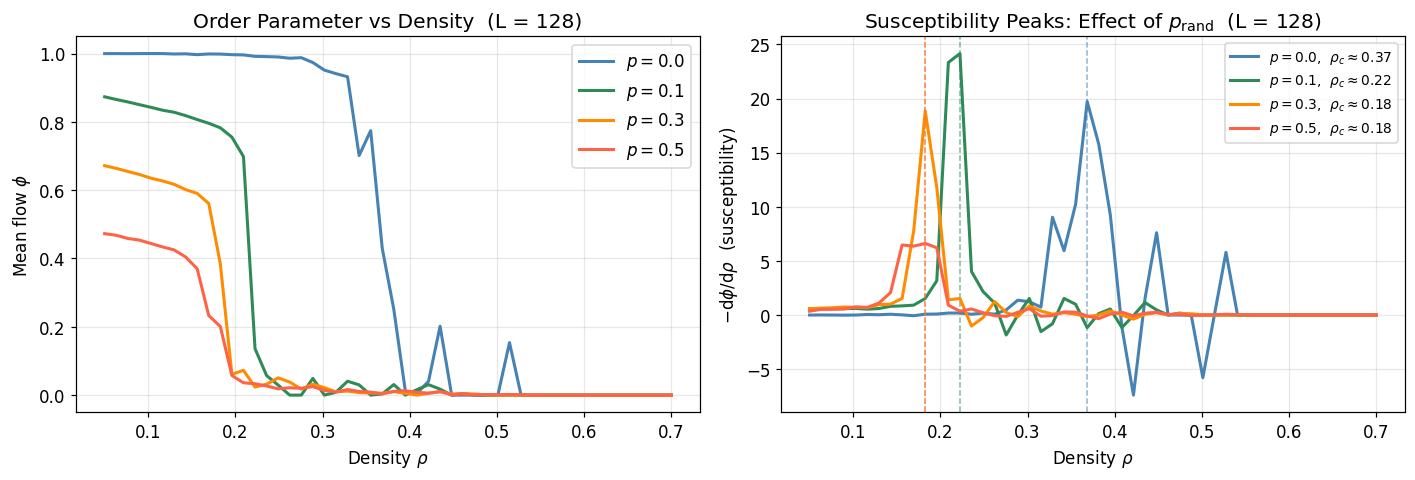

Critical densities by p_rand:
  p=0.0  ->  rho_c = 0.368
  p=0.1  ->  rho_c = 0.222
  p=0.3  ->  rho_c = 0.183
  p=0.5  ->  rho_c = 0.183


In [6]:
# ── Section 4: Phase transition analysis ──────────────────────────────────
rhos_fine  = np.linspace(0.05, 0.70, 50)
rho_c_by_p = {}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for p, col in zip(p_rand_vals, fd_colors):
    phi  = run_sweep_stochastic(L=128, densities=rhos_fine, p_rand=p)
    dphi = -np.gradient(phi, rhos_fine)
    rho_c_by_p[p] = float(rhos_fine[np.argmax(dphi)])

    axes[0].plot(rhos_fine, phi, '-', color=col, lw=2,
                 label=f'$p={p}$')
    axes[1].plot(rhos_fine, dphi, '-', color=col, lw=2,
                 label=f'$p={p}$,  $\\rho_c\\approx{rho_c_by_p[p]:.2f}$')
    axes[1].axvline(rho_c_by_p[p], color=col, ls='--', lw=1, alpha=0.6)

axes[0].set_xlabel('Density $\\rho$')
axes[0].set_ylabel('Mean flow $\\phi$')
axes[0].set_title('Order Parameter vs Density  (L = 128)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Density $\\rho$')
axes[1].set_ylabel('$-\\mathrm{d}\\phi/\\mathrm{d}\\rho$  (susceptibility)')
axes[1].set_title('Susceptibility Peaks: Effect of $p_{\\rm rand}$  (L = 128)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

rho_c_ref = rho_c_by_p[0.0]   # deterministic BML critical density — used throughout
print('Critical densities by p_rand:')
for p, rc in rho_c_by_p.items():
    print(f'  p={p}  ->  rho_c = {rc:.3f}')

## Section 5: Grid Snapshots

We compare the grid state after warmup for the **deterministic** ($p=0$) and
**stochastic** ($p=0.3$) models across three density regimes.

| Regime | What to look for |
|---|---|
| **Free flow** ($\rho=0.10$) | Sparse cars; stochastic case looks similar but slightly denser clusters |
| **Critical** ($\rho\approx\rho_c$) | Deterministic: sharp diagonal stripes; stochastic: stripes smeared or absent |
| **Gridlock** ($\rho=0.50$) | Deterministic: fully frozen; stochastic: may show small mobile patches |

**Colour coding** (same as `biham_middleton_levine.ipynb`):
- Blue = Horizontal car (→)
- Red = Vertical car (↑)
- White = Empty

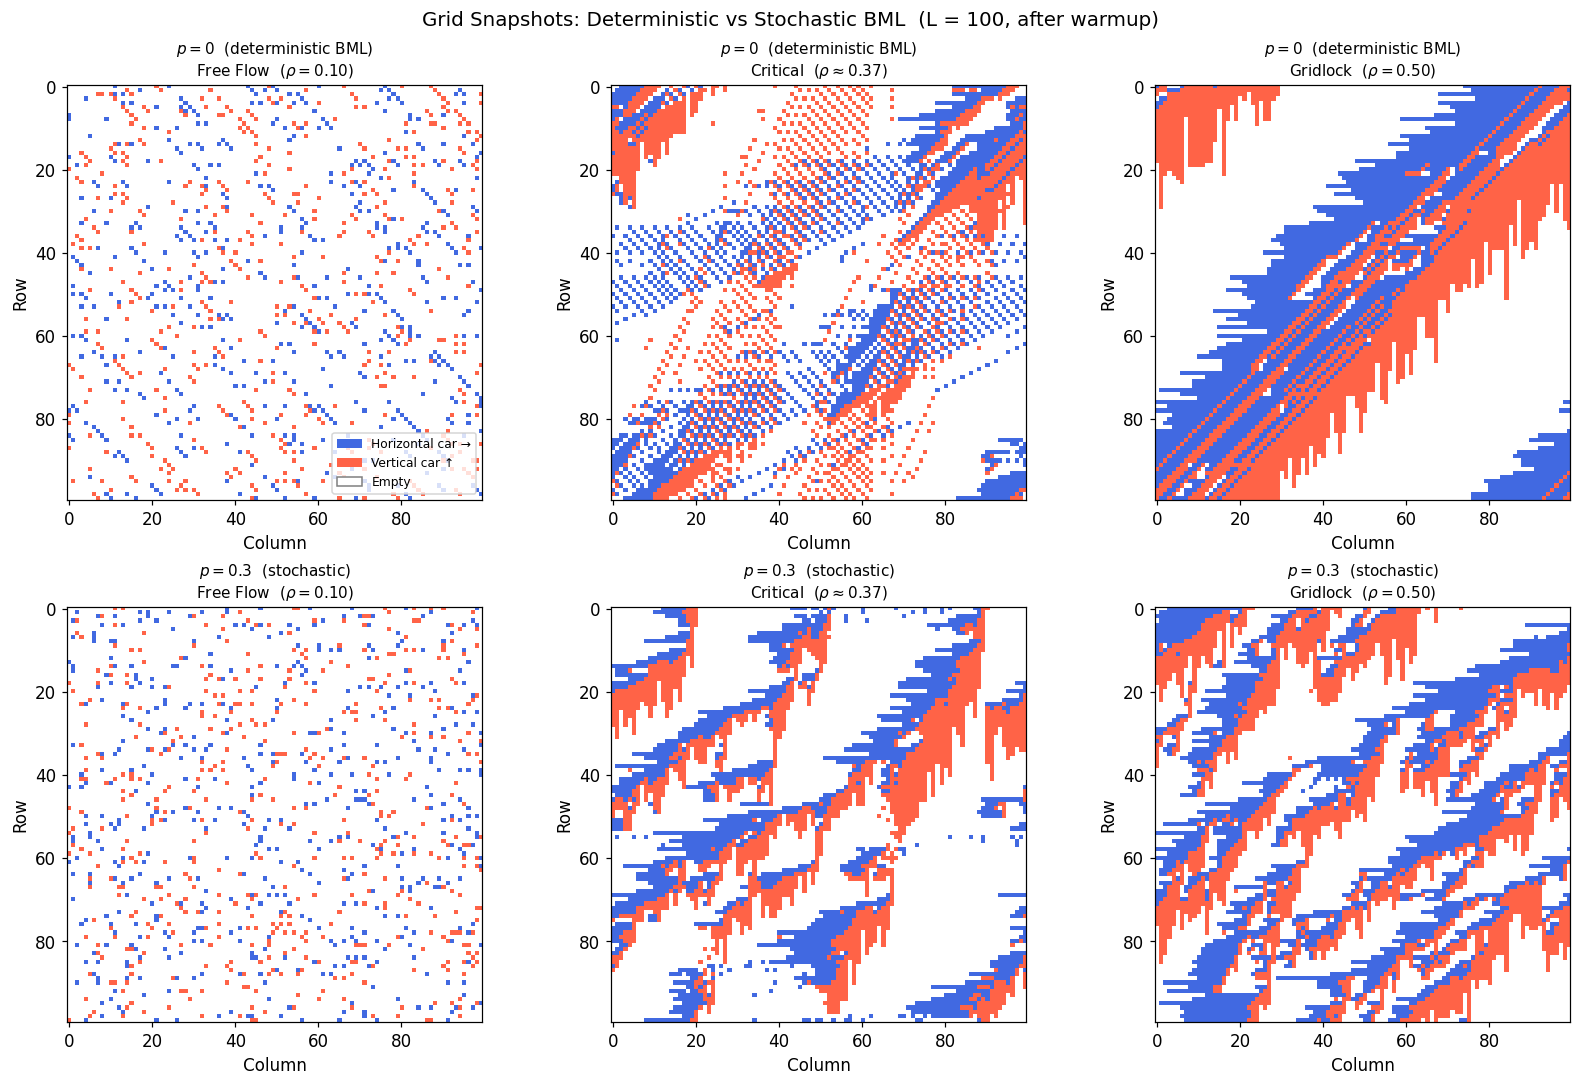

In [7]:
# ── Section 5: Grid snapshots ──────────────────────────────────────────────
cmap_bml = mcolors.ListedColormap(['white', 'royalblue', 'tomato'])
norm_bml = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_bml.N)

snap_rhos   = [0.10, rho_c_ref, 0.50]
snap_labels = [
    'Free Flow  ($\\rho=0.10$)',
    f'Critical  ($\\rho\\approx{rho_c_ref:.2f}$)',
    'Gridlock  ($\\rho=0.50$)',
]
legend_elems = [
    Patch(facecolor='royalblue', label='Horizontal car \u2192'),
    Patch(facecolor='tomato',    label='Vertical car \u2191'),
    Patch(facecolor='white', edgecolor='grey', label='Empty'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
row_configs = [(0.0, '$p=0$  (deterministic BML)'), (P_RAND, f'$p={P_RAND}$  (stochastic)')]

for row_idx, (p, row_label) in enumerate(row_configs):
    for col_idx, (rho, lbl) in enumerate(zip(snap_rhos, snap_labels)):
        sim = StochasticBML(L=L, density=rho, p_rand=p, seed=7)
        sim.warmup(T_WARMUP)
        axes[row_idx, col_idx].imshow(
            sim.get_snapshot(), cmap=cmap_bml, norm=norm_bml, interpolation='nearest')
        axes[row_idx, col_idx].set_title(f'{row_label}\n{lbl}', fontsize=10)
        axes[row_idx, col_idx].set_xlabel('Column')
        axes[row_idx, col_idx].set_ylabel('Row')

axes[0, 0].legend(handles=legend_elems, loc='lower right', fontsize=8)
fig.suptitle('Grid Snapshots: Deterministic vs Stochastic BML  (L = 100, after warmup)',
             fontsize=13)
plt.tight_layout()
plt.show()

## Section 5b: Grid Snapshots — With Traffic Lights

The same 2×3 panel as Section 5 ($p=0$ vs $p=0.3$), but with a 4×4 intersection grid
($T_{\text{cycle}} = 20$). Yellow squares mark intersection cells.

| Combination | What to observe |
|-------------|----------------|
| $p=0$, lights | Queues form squarely at intersections; stripes broken into rectangular blocks |
| $p=0.3$, lights | Queues are fuzzier; stochastic dawdling partially disperses waiting cars |


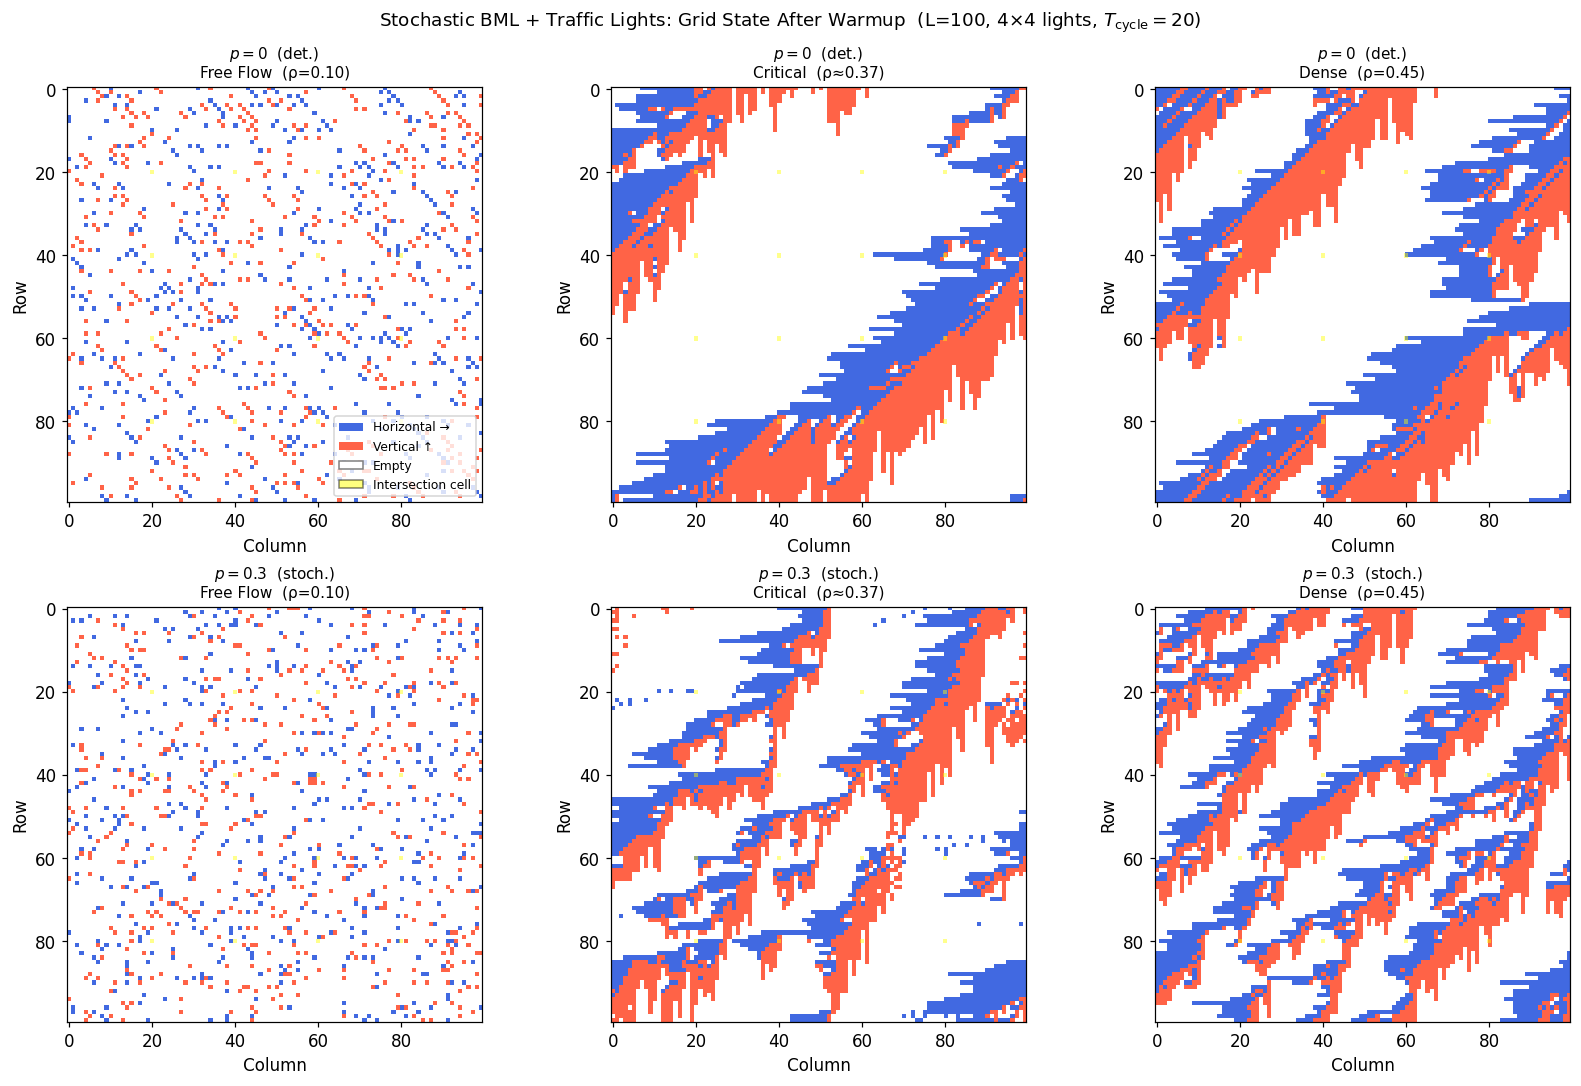

In [8]:
# ── Section 5b: Grid snapshots with traffic lights ───────────────────────
snap_scenarios_tl2 = [
    (0.10,      'Free Flow  (ρ=0.10)'),
    (rho_c_ref, f'Critical  (ρ≈{rho_c_ref:.2f})'),
    (0.45,      'Dense  (ρ=0.45)'),
]
legend_tl2 = [
    Patch(facecolor='royalblue', label='Horizontal →'),
    Patch(facecolor='tomato',    label='Vertical ↑'),
    Patch(facecolor='white', edgecolor='grey', label='Empty'),
    Patch(facecolor='yellow', edgecolor='black', alpha=0.5, label='Intersection cell'),
]
row_configs_tl = [(0.0, '$p=0$  (det.)'), (P_RAND, f'$p={P_RAND}$  (stoch.)')]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for row_idx, (p, row_label) in enumerate(row_configs_tl):
    for col_idx, (rho, title) in enumerate(snap_scenarios_tl2):
        ax = axes[row_idx, col_idx]
        sim = StochasticBMLWithLights(
            L=L, density=rho, p_rand=p, n_lights=4, T_cycle=20, seed=7)
        sim.warmup(T_WARMUP)
        ax.imshow(sim.grid.copy(), cmap=cmap_bml, norm=norm_bml, interpolation='nearest')
        for r in sim.light_rows:
            for c in sim.light_cols:
                ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                           linewidth=0, facecolor='yellow', alpha=0.45))
        ax.set_title(f'{row_label}\n{title}', fontsize=10)
        ax.set_xlabel('Column')
        ax.set_ylabel('Row')

axes[0, 0].legend(handles=legend_tl2, loc='lower right', fontsize=8)
fig.suptitle('Stochastic BML + Traffic Lights: Grid State After Warmup  '
             '(L=100, 4×4 lights, $T_{\\rm cycle}=20$)', fontsize=12)
plt.tight_layout()
plt.show()

## Section 6: Space–Time Diagrams

We track the binary occupancy of a fixed row ($y = L/2$) over 200 steps after warmup.

- **Rows** = time steps (top = early, bottom = later)
- **Columns** = road position along the chosen row
- **Black pixel** = occupied; **white** = empty

| Panel | Expected pattern |
|---|---|
| Deterministic free flow | Row mostly empty; cars pass quickly |
| Stochastic free flow | Similar, but denser and slightly slower streaks |
| Deterministic gridlock | Row freezes completely after brief transient |
| **Stochastic gridlock** | **Occasional gaps open up** — stochastic freezing can break a deadlock |

The last point is the key qualitative difference: unlike the deterministic model where
gridlock is a permanent absorbing state, stochasticity allows rare escape events.

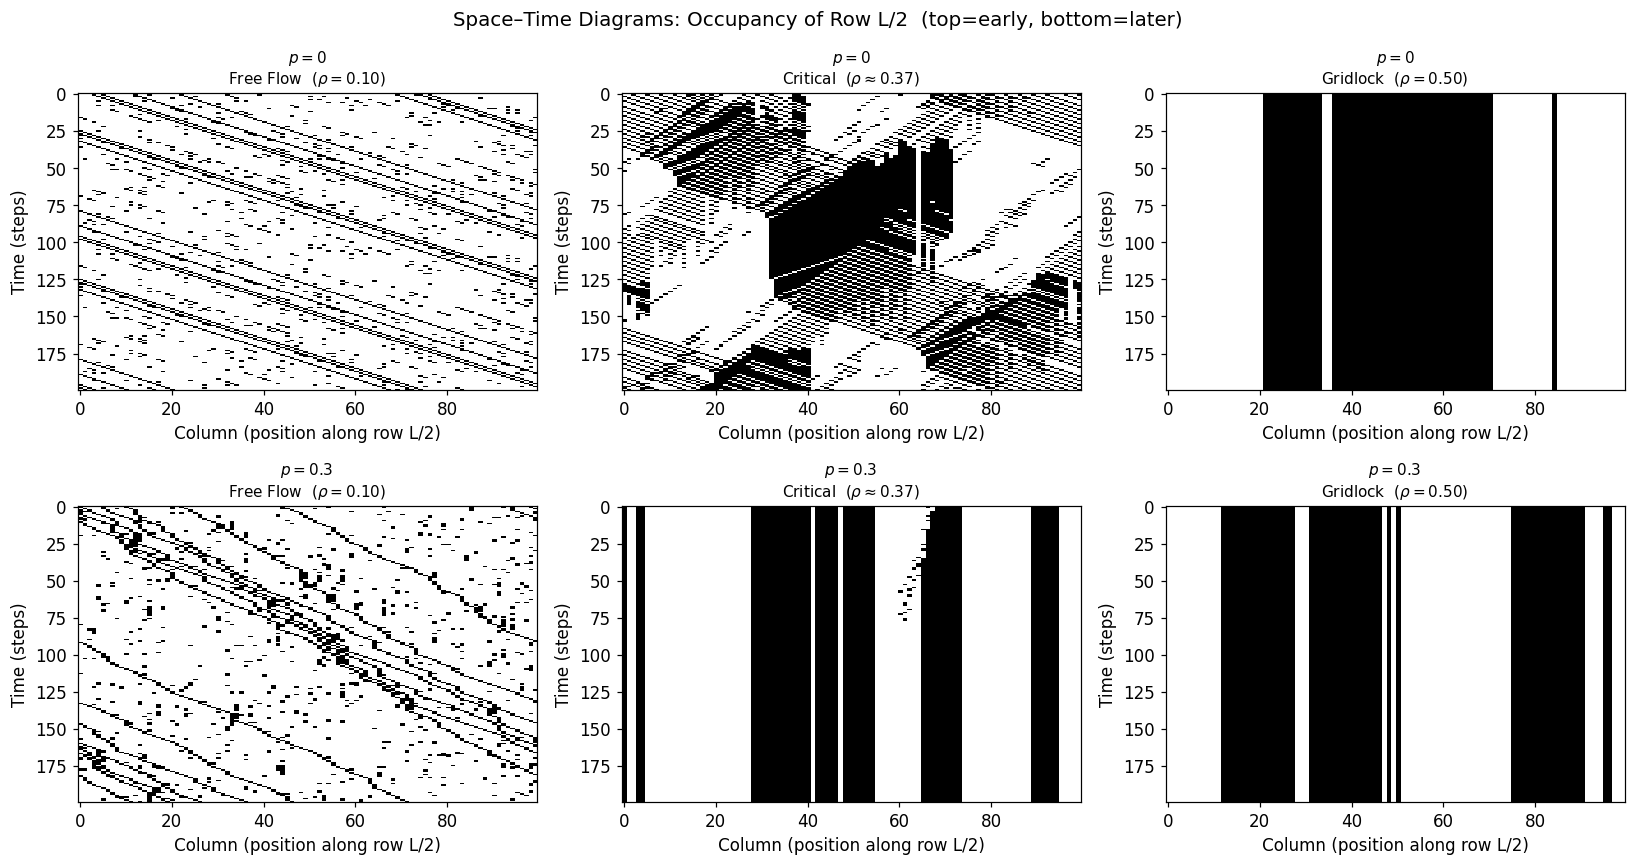

In [9]:
# ── Section 6: Space-time diagrams ────────────────────────────────────────
def record_spacetime_stochastic(rho, p_rand, L=100,
                                T_warmup=T_WARMUP, T_record=200, seed=7):
    sim    = StochasticBML(L=L, density=rho, p_rand=p_rand, seed=seed)
    sim.warmup(T_warmup)
    row    = L // 2
    frames = np.zeros((T_record, L), dtype=np.int8)
    for t in range(T_record):
        sim.step()
        frames[t] = (sim.grid[row] > 0).astype(np.int8)
    return frames


st_scenarios = [
    (0.10,      'Free Flow  ($\\rho=0.10$)'),
    (rho_c_ref, f'Critical  ($\\rho\\approx{rho_c_ref:.2f}$)'),
    (0.50,      'Gridlock  ($\\rho=0.50$)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col_idx, (rho, title) in enumerate(st_scenarios):
    for row_idx, (p, p_label) in enumerate([(0.0, '$p=0$'), (P_RAND, f'$p={P_RAND}$')]):
        frames = record_spacetime_stochastic(rho=rho, p_rand=p)
        axes[row_idx, col_idx].imshow(
            frames, cmap='binary', interpolation='nearest', aspect='auto')
        axes[row_idx, col_idx].set_title(f'{p_label}\n{title}', fontsize=10)
        axes[row_idx, col_idx].set_xlabel('Column (position along row L/2)')
        axes[row_idx, col_idx].set_ylabel('Time (steps)')

fig.suptitle('Space\u2013Time Diagrams: Occupancy of Row L/2  (top=early, bottom=later)',
             fontsize=13)
plt.tight_layout()
plt.show()

## Section 7: Effect of $p_{\text{rand}}$ on Flow

Holding density fixed, we sweep $p_{\text{rand}} \in [0,\, 0.9]$ at three densities.

| Density regime | Expected trend with increasing $p_{\text{rand}}$ |
|---|---|
| Free flow ($\rho=0.10$) | Monotone decrease — every freeze directly wastes capacity |
| Critical ($\rho\approx\rho_c$) | Non-monotone possible — small $p$ may break proto-jams |
| Dense ($\rho=0.45$) | May increase slightly — stochastic unfreezing can escape gridlock |

This is analogous to the role of noise in preventing deterministic deadlocks in
other self-organised systems (e.g. Brownian motion helping particles escape local minima).

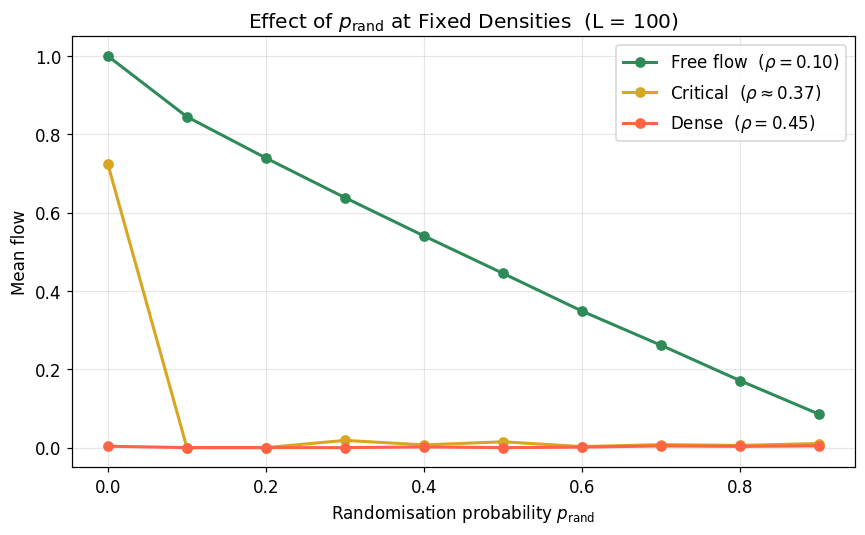

In [10]:
# ── Section 7: Effect of p_rand at fixed densities ─────────────────────────
p_rand_sweep    = np.linspace(0.0, 0.9, 10)
fixed_densities = [
    (0.10,      'Free flow  ($\\rho=0.10$)',           'seagreen'),
    (rho_c_ref, f'Critical  ($\\rho\\approx{rho_c_ref:.2f}$)', 'goldenrod'),
    (0.45,      'Dense  ($\\rho=0.45$)',               'tomato'),
]

fig, ax = plt.subplots(figsize=(8, 5))
for rho, label, col in fixed_densities:
    flows_p = np.zeros(len(p_rand_sweep))
    for j, p in enumerate(p_rand_sweep):
        sim = StochasticBML(L=L, density=rho, p_rand=p, seed=j + 10)
        sim.warmup(T_WARMUP)
        flows_p[j] = sim.run(T_MEASURE)
    ax.plot(p_rand_sweep, flows_p, 'o-', color=col, lw=2, ms=6, label=label)

ax.set_xlabel('Randomisation probability $p_{\\rm rand}$')
ax.set_ylabel('Mean flow')
ax.set_title('Effect of $p_{\\rm rand}$ at Fixed Densities  (L = 100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 8: Stochastic BML with Traffic Lights

`StochasticBMLWithLights` combines both extensions:

1. **Intersection blocking** (from `BMLWithLights`): when a light is red for a
   given direction, cars heading into an intersection cell are blocked even if
   the cell is otherwise empty.
2. **Stochastic dawdling** (from `StochasticBML`): even after passing the
   emptiness and light checks, each car is frozen with probability $p_{\text{rand}}$.

We compare four scenarios to isolate the contributions:

| Scenario | Model |
|---|---|
| $p=0$, no lights | Deterministic BML |
| $p=0.3$, no lights | Stochastic BML |
| $p=0$, lights | BML with lights only |
| $p=0.3$, lights | Full stochastic BML + lights |

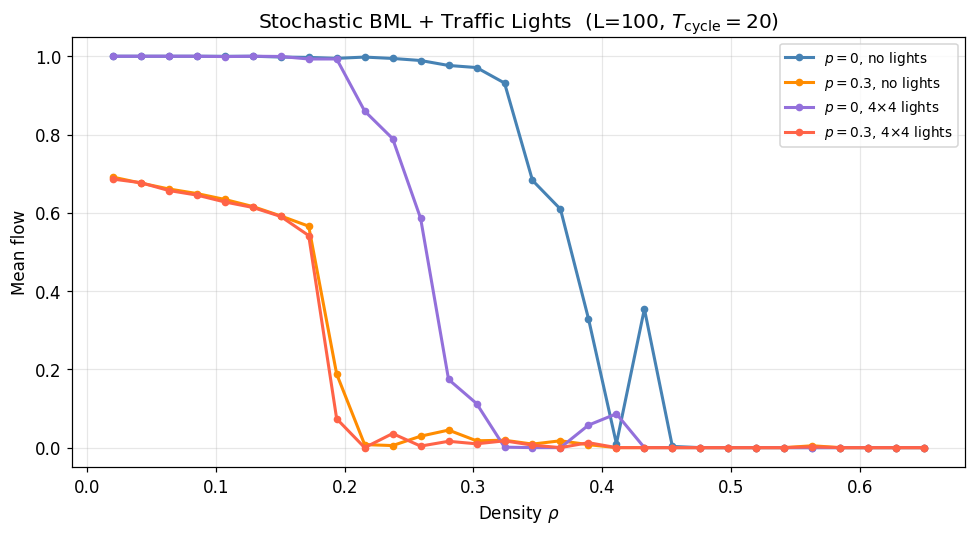

In [11]:
# ── Section 8c: Fundamental diagram — four scenarios ──────────────────────
def run_sweep_with_lights(L, densities, p_rand, n_lights=4, T_cycle=20,
                          T_warmup=T_WARMUP, T_measure=T_MEASURE, seed_offset=0):
    flows = np.zeros(len(densities))
    for i, rho in enumerate(densities):
        sim = StochasticBMLWithLights(
            L=L, density=rho, p_rand=p_rand,
            n_lights=n_lights, T_cycle=T_cycle, seed=seed_offset + i)
        sim.warmup(T_warmup)
        flows[i] = sim.run(T_measure)
    return flows


rhos_tl = np.linspace(0.02, 0.65, 30)
configs = [
    (0.0,   False, 'steelblue',    '$p=0$, no lights'),
    (P_RAND, False, 'darkorange',  f'$p={P_RAND}$, no lights'),
    (0.0,   True,  'mediumpurple', '$p=0$, 4\u00d74 lights'),
    (P_RAND, True,  'tomato',      f'$p={P_RAND}$, 4\u00d74 lights'),
]

fig, ax = plt.subplots(figsize=(9, 5))
for p, use_lights, col, label in configs:
    if use_lights:
        flows = run_sweep_with_lights(L=L, densities=rhos_tl, p_rand=p)
    else:
        flows = run_sweep_stochastic(L=L, densities=rhos_tl, p_rand=p)
    ax.plot(rhos_tl, flows, 'o-', color=col, lw=2, ms=4, label=label)

ax.set_xlabel('Density $\\rho$')
ax.set_ylabel('Mean flow')
ax.set_title('Stochastic BML + Traffic Lights  (L=100, $T_{\\rm cycle}=20$)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

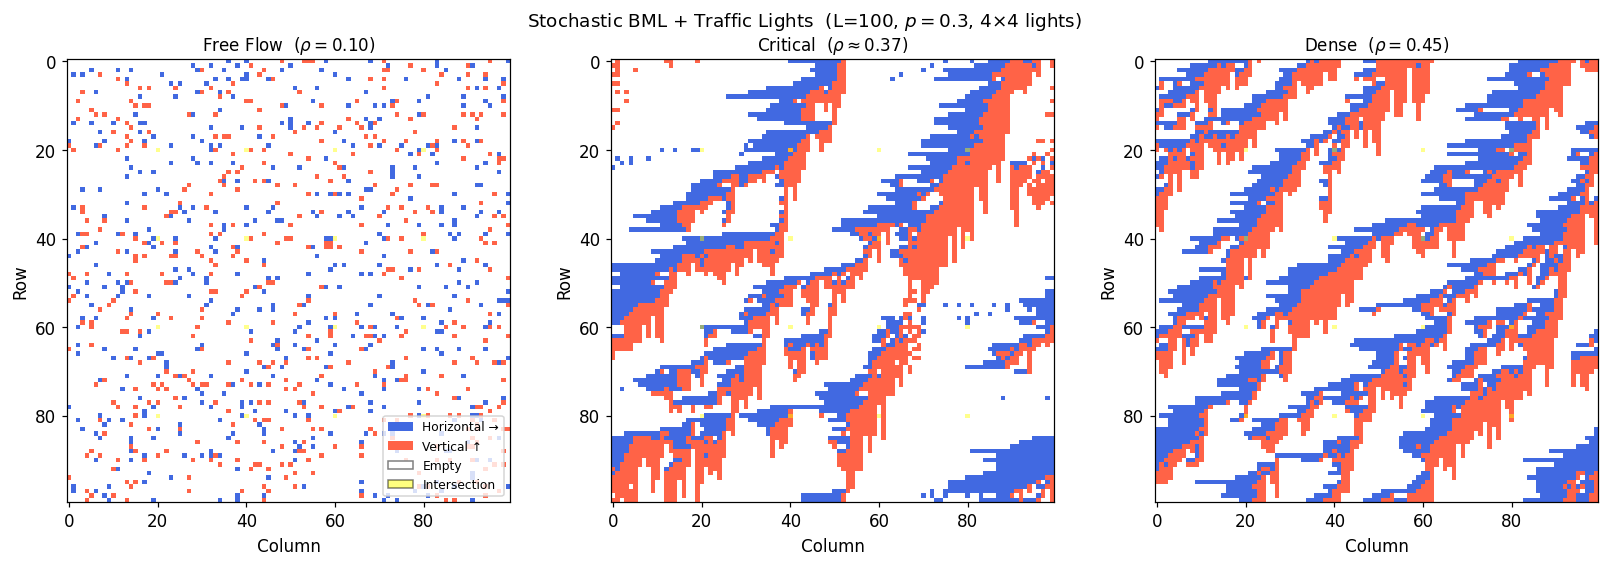

In [12]:
# ── Section 8d: Grid snapshots with intersection overlay ──────────────────
snap_scenarios_tl = [
    (0.10,      'Free Flow  ($\\rho=0.10$)'),
    (rho_c_ref, f'Critical  ($\\rho\\approx{rho_c_ref:.2f}$)'),
    (0.45,      'Dense  ($\\rho=0.45$)'),
]
legend_tl = [
    Patch(facecolor='royalblue', label='Horizontal \u2192'),
    Patch(facecolor='tomato',    label='Vertical \u2191'),
    Patch(facecolor='white', edgecolor='grey', label='Empty'),
    Patch(facecolor='yellow', edgecolor='black', alpha=0.5, label='Intersection'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (rho, title) in zip(axes, snap_scenarios_tl):
    sim = StochasticBMLWithLights(L=L, density=rho, p_rand=P_RAND,
                                   n_lights=4, T_cycle=20, seed=7)
    sim.warmup(T_WARMUP)
    ax.imshow(sim.grid.copy(), cmap=cmap_bml, norm=norm_bml, interpolation='nearest')
    for r in sim.light_rows:
        for c in sim.light_cols:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                       linewidth=0, facecolor='yellow', alpha=0.45))
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')

axes[0].legend(handles=legend_tl, loc='lower right', fontsize=8)
fig.suptitle(f'Stochastic BML + Traffic Lights  (L=100, $p={P_RAND}$, 4\u00d74 lights)',
             fontsize=12)
plt.tight_layout()
plt.show()

## Section 9: Summary

### Key Findings

1. **Stochasticity softens the phase transition**: increasing $p_{\text{rand}}$
   smooths the sharp BML discontinuity — the transition broadens and shifts toward
   lower $\rho_c$ as more cars are randomly frozen.

2. **Free-flow cost**: randomisation always reduces throughput in the free-flow
   regime ($\rho < \rho_c$) because it wastes movement opportunities.

3. **Near-gridlock benefit**: at densities slightly above the deterministic
   $\rho_c$, stochasticity can partially unjam configurations that would otherwise
   be permanent absorbing states.

4. **Gridlock becomes probabilistic**: unlike the deterministic BML where gridlock
   is irreversible, the stochastic model can escape near-gridlock — visible in the
   space-time diagrams as intermittent gaps in the dense regime.

5. **Traffic lights compound the effect**: combining lights and $p_{\text{rand}}$
   reduces both peak flow and shifts $\rho_c$; the effects are approximately additive.

6. **NaSch analogy**: the role of $p_{\text{rand}}$ here mirrors its role in 1-D NaSch,
   where dawdling nucleates stop-and-go waves — here it nucleates temporary partial jams
   in the 2-D grid.

See `biham_middleton_levine.ipynb` for the deterministic BML baseline and
`nagel_schreckenberg.ipynb` for the 1-D stochastic comparison.

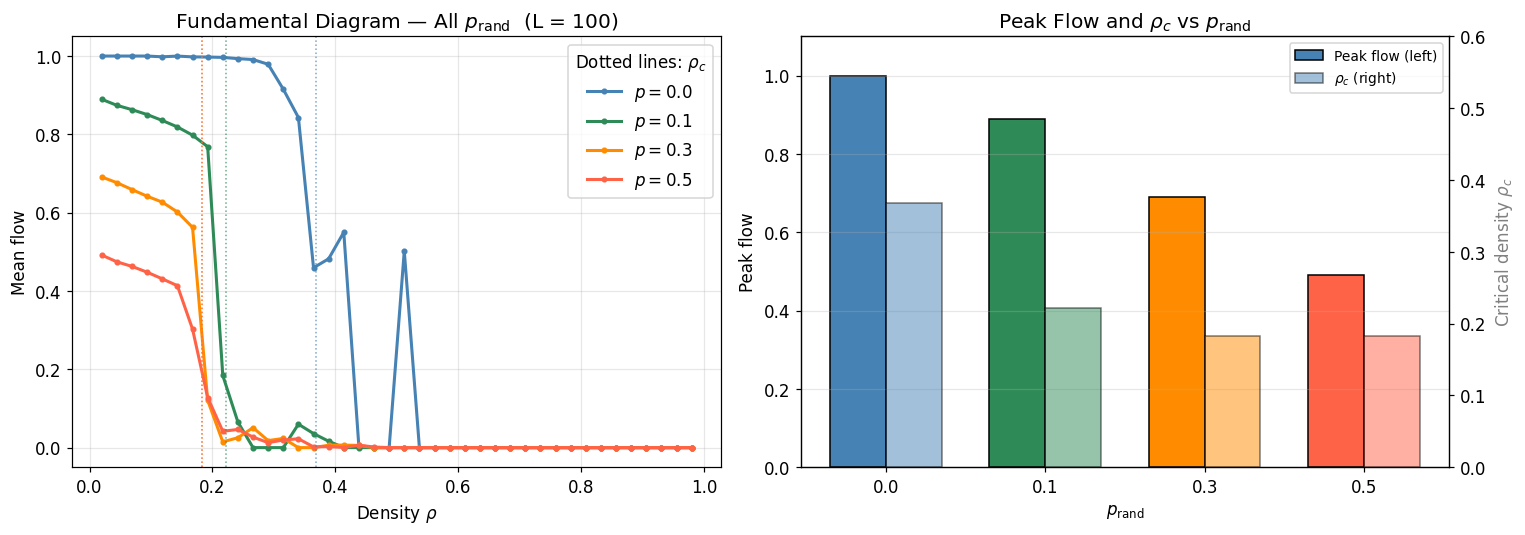


Summary table:
    p_rand     peak_flow     rho_c
       0.0        1.0000     0.368
       0.1        0.8894     0.222
       0.3        0.6912     0.183
       0.5        0.4917     0.183


In [13]:
# ── Section 9: Summary plots ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlay fundamental diagrams for all p_rand values
for p, col in zip(p_rand_vals, fd_colors):
    axes[0].plot(densities_fd, all_flows[p], 'o-', color=col, lw=2, ms=3,
                 label=f'$p={p}$')
for p, col in zip(p_rand_vals, fd_colors):
    axes[0].axvline(rho_c_by_p[p], color=col, ls=':', lw=1, alpha=0.7)

axes[0].set_xlabel('Density $\\rho$')
axes[0].set_ylabel('Mean flow')
axes[0].set_title('Fundamental Diagram — All $p_{\\rm rand}$  (L = 100)')
axes[0].legend(title='Dotted lines: $\\rho_c$')
axes[0].grid(True, alpha=0.3)

# Right: bar chart — peak flow and rho_c as a function of p_rand
peak_flows = [float(np.max(all_flows[p])) for p in p_rand_vals]
rho_c_vals = [rho_c_by_p[p] for p in p_rand_vals]

x      = np.arange(len(p_rand_vals))
width  = 0.35
ax2    = axes[1].twinx()
bars1  = axes[1].bar(x - width/2, peak_flows, width, color=fd_colors,
                     edgecolor='black', label='Peak flow (left)')
bars2  = ax2.bar(x + width/2, rho_c_vals, width, color=fd_colors,
                 edgecolor='black', alpha=0.5, label='$\\rho_c$ (right)')

axes[1].set_xlabel('$p_{\\rm rand}$')
axes[1].set_ylabel('Peak flow', color='black')
ax2.set_ylabel('Critical density $\\rho_c$', color='grey')
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(p) for p in p_rand_vals])
axes[1].set_title('Peak Flow and $\\rho_c$ vs $p_{\\rm rand}$')
axes[1].set_ylim(0, 1.1)
ax2.set_ylim(0, 0.6)
axes[1].grid(True, alpha=0.3, axis='y')

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.show()

print('\nSummary table:')
print(f'{"p_rand":>10}  {"peak_flow":>12}  {"rho_c":>8}')
for p, pf, rc in zip(p_rand_vals, peak_flows, rho_c_vals):
    print(f'{p:>10.1f}  {pf:>12.4f}  {rc:>8.3f}')